#  Generative AI Model (VAE) to Predict Gene Expression from Drug SMILES (Part I)

### Project Introduction

This project tackles a core challenge in drug discovery: predicting how a drug will affect a cell's biology before it's ever tested in the lab. 
```
Gene Expression Change = f(Drug, Cell Type)
```
We use the LINCS L1000 (GSE92742) dataset, because it is the gold-standard, largest, and most comprehensive public resource designed for exactly this project's goal: predicting how a cell's gene expression changes in response to a drug. The dataset contains each variable in the equation above:

  * **Gene Expression Change**: It contains the gene expression changes (the Z-scores in the .gctx file).

  * **Drug**: It tells you which drug was used for each experiment (in the sig_info and pert_info files).

  * **Cell Type**: It tells you which cell type was used (also in the sig_info file)

This project aims to build and refine a Conditional Variational Autoencoder (CVAE) to predict how a drug's chemical structure will alter gene expression in cells. By training on a large dataset of known drug effects, the model learns a compressed, meaningful "latent space" that represents the complex biological responses to different compounds. 

The ultimate goal is not just to reconstruct existing data accurately but to use this learned understanding to generate plausible gene expression profiles for entirely new, unseen drugs, a key task in modern drug discovery. The process involves a semi-supervised approach, incorporating a classifier to predict a drug's mechanism of action (MoA) to better organize this latent space. 

This project is broken into two parts:

* **Part I** (This Notebook): This phase is comprised of exploratory data analysis, definition of the data ingestion pipeline and model training.

* **Part II**: This phase builds on the first phase to optimize the cVAE to ensure that the model is generating biologically relevant data by iterating and validating the model against Gene Set Enrichment Analysis.


--- 
### References

**Data Sources and Platforms**

* [LINCS L1000 (GSE92742)](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE92742): The data used here is the LINCS L1000 - the gold-standard, largest and most comprehensive public resource designed for predicting how a cell's gene expression changes in response to a drug.

* [Broad Institute's Drug Repurposing Hub](https://repo-hub.broadinstitute.org/repurposing#download-data): This data contains the Mechanism of Action (MoA)for each compound in the LINCS L1000 dataset, primarily curated and maintained by the Broad Institute through resources like the Drug Repurposing Hub.

**Libraries**
* [RDKit](https://www.rdkit.org/docs/#): Open-source cheminformatics toolkit widely used for computational chemistry and drug discovery. It provides a powerful suite of tools for working with chemical structures, including methods for reading and writing molecular file formats, generating 2D and 3D molecular representations, and calculating chemical descriptors and fingerprints

---
### Table of Contents

1. [Imports](#imports)
2. [Constants & Data Import](#constants-&-data-import)
3. [Utility Functions](#utility-functions)
4. [Data Exploration](#data-exploration)
5. [Feature Engineering](#feature-engineering)
6. [Train the Model](#train-the-model) 
7. [Summary](#summary)

---
### 1. Imports <a class="anchor" id="imports"></a>

In [1]:
import os
from pathlib import Path
from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
import numpy as np

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from typing import Any
from tqdm import tqdm

import wandb
import imageio

import yaml
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA

---
### 2. Constants & Data Import <a class="anchor" id="constants"></a>


The necessary data files can be accessed and downloaded via the [Gene Expression Omnibus Portal](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE92742). The following specific datasets are required:

* **The Gene Expression Data**

    *GSE92742_Broad_LINCS_Level5_COMPZ.MODZ_n473647x12328.gctx.gz* 
    
    The main data matrix that contains the results of nearly half a million experiments (how much a gene's expression went up or down in a single experiment compared to a control)

* **The Signature Info File**

    *GSE92742_Broad_LINCS_sig_info.txt*

    Metadata file that explains what each column in the expression matrix means.

* **The Perturbation Info File**

    *GSE92742_Broad_LINCS_pert_info.txt*

    The drug dictionary that provides details about the perturbations used in the experiments.

* **The Gene Info File**

    *GSE92742_Broad_LINCS_gene_info.txt*

    The gene dictionary that provides details about the genes measured.


The notebook expects both tsv files to be placed in the `data/LINCS_L1000` folder.

In [2]:
ROOT = Path(os.getcwd()).parents[1]

PROCESSED_DATA_PATH = os.path.join(
    ROOT, "data", "processed", "drug_induced_gene_expression_prediction"
)

df_train = pd.read_parquet(os.path.join(PROCESSED_DATA_PATH, "train_data.parquet"))
df_val = pd.read_parquet(os.path.join(PROCESSED_DATA_PATH, "val_data.parquet"))
df_test = pd.read_parquet(os.path.join(PROCESSED_DATA_PATH, "test_data.parquet"))

df_meta_train = pd.read_parquet(os.path.join(PROCESSED_DATA_PATH, "train_meta.parquet"))
df_meta_val = pd.read_parquet(os.path.join(PROCESSED_DATA_PATH, "val_meta.parquet"))
df_meta_test = pd.read_parquet(os.path.join(PROCESSED_DATA_PATH, "test_meta.parquet"))

---
### 3. Utility Functions <a class="anchor" id="utility"></a>

#### Data Loader

In [3]:
class LincsDataset(Dataset):
    """Dataset for LINCS drug-induced gene expression prediction."""

    def __init__(self, df_expression: pd.DataFrame, df_meta: pd.DataFrame):
        """
        Args:
            df_expression (pd.DataFrame): DataFrame containing gene expression data with genes as columns and samples pert_ids as rows.
            fingerprint_map (Dict[str, np.ndarray]): Dictionary mapping perturbation IDs to their corresponding fingerprints.
        """
        self.df_expression = df_expression
        self.df_meta = df_meta
        # Ensure that the perturbation IDs in the expression data match those in the metadata
        self.pert_ids = df_expression.index.intersection(self.df_meta.index).tolist()

        self.df_expression = df_expression.loc[self.pert_ids]
        self.df_meta = df_meta.loc[self.pert_ids]

    def __len__(self):
        """Returns the number of samples in the dataset."""
        return len(self.df_expression)

    def __getitem__(self, idx: int) -> Tuple[np.ndarray, np.ndarray]:
        """Returns the fingerprint and gene expression values for a given index.
        Args:
            idx (int): Index of the sample to retrieve.
        Returns:
            Tuple[np.ndarray, np.ndarray]: A tuple containing the fingerprint and the gene expression values.
        """
        if idx < 0 or idx >= len(self):
            raise IndexError("Index out of bounds for dataset.")

        pert_id = self.pert_ids[idx]
        if pert_id not in self.df_meta.index:
            raise KeyError(f"Perturbation ID {pert_id} not found in metadata.")

        # Convert to PyTorch tensors
        expression_tensor = torch.tensor(
            self.df_expression.loc[pert_id].values, dtype=torch.float
        )
        fingerprint_tensor = torch.tensor(
            self.df_meta.loc[pert_id, "fingerprint"], dtype=torch.float
        )
        moa_label_tensor = torch.tensor(
            self.df_meta.loc[pert_id, "moa_int"], dtype=torch.int64
        )

        return fingerprint_tensor, expression_tensor, moa_label_tensor

    def get_item_by_pert_id(self, pert_id: str) -> Tuple[np.ndarray, np.ndarray]:
        """Returns the fingerprint and gene expression values for a given perturbation ID.
        Args:
            pert_id (str): Perturbation ID to retrieve.
        Returns:
            Tuple[np.ndarray, np.ndarray]: A tuple containing the fingerprint and the gene expression values.
        """
        if pert_id not in self.df_meta.index:
            raise KeyError(f"Perturbation ID {pert_id} not found in metadata.")

        expression_tensor = torch.tensor(
            self.df_expression.loc[pert_id].values, dtype=torch.float
        )
        fingerprint_tensor = torch.tensor(
            self.df_meta.loc[pert_id, "fingerprint"], dtype=torch.float
        )
        moa_label_tensor = torch.tensor(
            self.df_meta.loc[pert_id, "moa_int"], dtype=torch.int64
        )

        return fingerprint_tensor, expression_tensor, moa_label_tensor

#### Model Architecture

**Encoder**

This module takes the gene expression data and the embedded chemical fingerprint as input and compresses them into a lower-dimensional latent space. It doesn't output a single point, but rather the parameters—mean (mu) and log-variance (logvar)—of a probability distribution.

In [4]:
class Encoder(torch.nn.Module):
    """Encoder for the Conditional Variational Autoencoder (CVAE).

    Encodes input data into latent space parameters (mean and log-variance).
    """

    def __init__(
        self,
        input_dim: int,
        hidden_dim: int,
        latent_dim: int,
        num_layers: int = 0,
        dropout_rate: float = 0.2,
    ) -> None:
        """
        Args:
            input_dim (int): Dimension of the input data.
            hidden_dim (int): Dimension of the hidden layer.
            latent_dim (int): Dimension of the latent space.
            num_layers (int, optional): Number of hidden layers. Defaults to 0.
            dropout_rate (float, optional): Dropout rate. Defaults to 0.2.
        """
        super(Encoder, self).__init__()

        self.fc_initial = nn.Linear(input_dim, hidden_dim * (num_layers + 1))

        self.fc_layers = nn.ModuleList()
        if num_layers > 0:
            for layer_mult in range(1, num_layers + 1)[::-1]:
                self.fc_layers.append(
                    nn.Linear(hidden_dim * (layer_mult + 1), hidden_dim * layer_mult)
                )

        self.dropout = nn.Dropout(p=dropout_rate)

        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Forward pass through the encoder.

        Args:
            x (torch.Tensor): Input tensor.

        Returns:
            Tuple[torch.Tensor, torch.Tensor]: Mean and log-variance tensors.
        """
        x = torch.relu(self.fc_initial(x))
        x = self.dropout(x)

        for fc_layer in self.fc_layers:
            x = torch.relu(fc_layer(x))
            x = self.dropout(x)

        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)

        return mu, logvar


**Decoder**

This module performs the reverse operation. It takes a sample (z) from the latent space and the embedded chemical fingerprint and decompresses them, attempting to reconstruct the original gene expression data.

In [5]:
class Decoder(torch.nn.Module):
    """Decoder for the Conditional Variational Autoencoder (CVAE).

    Decodes latent variables and condition embeddings to reconstruct input data.
    """

    def __init__(
        self,
        input_dim: int,
        hidden_dim: int,
        output_dim: int,
        num_layers: int = 0,
        dropout_rate: float = 0.2,
    ) -> None:
        """
        Args:
            input_dim (int): Dimension of the input latent vector.
            hidden_dim (int): Dimension of the hidden layer.
            output_dim (int): Dimension of the output data.
            num_layers (int, optional): Number of hidden layers. Defaults to 0.
            dropout_rate (float, optional): Dropout rate. Defaults to 0.2.
        """
        super(Decoder, self).__init__()

        self.dropout = nn.Dropout(p=dropout_rate)

        self.fc_initial = nn.Linear(input_dim, hidden_dim * 8)

        self.fc_layers = nn.ModuleList()
        if num_layers > 0:
            for layer_mult in range(1, num_layers + 1):
                self.fc_layers.append(
                    nn.Sequential(
                        nn.Linear(
                            hidden_dim * layer_mult * 8,
                            hidden_dim * (layer_mult + 1) * 8,
                        ),
                        nn.BatchNorm1d(hidden_dim * (layer_mult + 1) * 8),
                        nn.ReLU(),
                        nn.Dropout(p=dropout_rate),
                    )
                )

        self.fc_final = nn.Linear(hidden_dim * (num_layers + 1) * 8, output_dim)

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        """
        Forward pass through the decoder.

        Args:
            z (torch.Tensor): Latent variable concatenated with condition embedding.

        Returns:
            torch.Tensor: Reconstructed input tensor.
        """
        x = torch.relu(self.fc_initial(z))
        x = self.dropout(x)

        for fc_layer in self.fc_layers:
            x = fc_layer(x)

        x_reconstructed = self.fc_final(x)

        return x_reconstructed


**Classification Head**

This is a simple classifier that takes the stable representation of the data from the latent space (mu) and tries to predict a class label, such as the drug's Mechanism of Action (MoA) (the "supervised" part of the model).

In [6]:
class ClassificationHead(torch.nn.Module):
    """Classification head for the Conditional Variational Autoencoder (CVAE).

    Maps latent variables to class logits.
    """

    def __init__(
        self,
        latent_dim: int,
        output_dim: int,
        dropout_rate: float = 0.3,
    ) -> None:
        """
        Args:
            latent_dim (int): Dimension of the latent space.
            output_dim (int): Number of output classes.
            dropout_rate (float, optional): Dropout rate. Defaults to 0.3.
        """
        super(ClassificationHead, self).__init__()

        self.fc_initial = nn.Linear(latent_dim, output_dim)
        self.dropout = nn.Dropout(p=dropout_rate)

    def forward(self, mu: torch.Tensor) -> torch.Tensor:
        """
        Forward pass through the classification head.

        Args:
            mu (torch.Tensor): Latent mean tensor.

        Returns:
            torch.Tensor: Logits for classification.
        """
        logits = self.fc_initial(mu)
        return logits


**Molecular Embedding Module**

This is a dedicated sub-network whose only job is to take the large, raw chemical fingerprint (e.g., 2048 bits) and compress it into a smaller, dense feature vector. This creates a more meaningful representation of the compound before it's used by the encoder and decoder.

In [7]:
class MolecularEmbedding(torch.nn.Module):
    """Molecular embedding layer for the Conditional Variational Autoencoder (CVAE).

    Embeds condition (e.g., molecular fingerprint) data.
    """

    def __init__(
        self,
        condition_dim: int = 2048,
        condition_emb_dim: int = 64,
        num_layers: int = 0,
        dropout_rate: float = 0.2,
    ) -> None:
        """
        Args:
            condition_dim (int, optional): Dimension of the condition data. Defaults to 2048.
            condition_emb_dim (int, optional): Dimension of the embedded condition data. Defaults to 64.
            num_layers (int, optional): Number of hidden layers. Defaults to 0.
            dropout_rate (float, optional): Dropout rate. Defaults to 0.2.
        """
        super(MolecularEmbedding, self).__init__()
        self.fc_initial = nn.Linear(condition_dim, condition_emb_dim * (num_layers + 1))

        self.fc_layers = nn.ModuleList()
        if num_layers > 0:
            for layer_mult in range(1, num_layers + 1)[::-1]:
                self.fc_layers.append(
                    nn.Linear(
                        condition_emb_dim * (layer_mult + 1),
                        condition_emb_dim * layer_mult,
                    )
                )

        self.dropout = nn.Dropout(p=dropout_rate)

    def forward(self, c: torch.Tensor) -> torch.Tensor:
        """
        Forward pass through the molecular embedding layer.

        Args:
            c (torch.Tensor): Condition (fingerprint) tensor.

        Returns:
            torch.Tensor: Embedded condition tensor.
        """
        c = torch.relu(self.fc_initial(c))
        for fc_layer in self.fc_layers:
            c = torch.relu(fc_layer(c))
            c = self.dropout(c)
        return c


**Conditional Variational Autoencoder**

This is the main, top-level module that assembles all the other pieces. It orchestrates the end-to-end flow of data: embedding the fingerprint, passing data through the encoder to get the latent parameters, sampling from the latent space, and passing the result through the decoder to get the final reconstruction. It also contains the ClassificationHead for the semi-supervised task.

In [8]:
class CVAE(torch.nn.Module):
    """Conditional Variational Autoencoder for drug-induced gene expression prediction.

    Combines encoder, decoder, molecular embedding, and classification head.
    """

    def __init__(
        self,
        expression_dim: int,
        num_classes: int,
        num_encoder_layers: int = 0,
        encoder_dropout_rate: float = 0.2,
        num_decoder_layers: int = 0,
        decoder_dropout_rate: float = 0.2,
        condition_dim: int = 2048,
        condition_emb_dim: int = 64,
        hidden_dim: int = 512,
        latent_dim: int = 128,
        num_molecular_emb_layers: int = 0,
    ) -> None:
        """
        Args:
            expression_dim (int): Dimension of the gene expression data.
            num_classes (int): Number of output classes.
            num_encoder_layers (int, optional): Number of encoder layers. Defaults to 0.
            encoder_dropout_rate (float, optional): Encoder dropout rate. Defaults to 0.2.
            num_decoder_layers (int, optional): Number of decoder layers. Defaults to 0.
            decoder_dropout_rate (float, optional): Decoder dropout rate. Defaults to 0.2.
            condition_dim (int, optional): Dimension of the condition data. Defaults to 2048.
            condition_emb_dim (int, optional): Dimension of the embedded condition data. Defaults to 64.
            hidden_dim (int, optional): Hidden dimension for encoder/decoder. Defaults to 512.
            latent_dim (int, optional): Dimension of the latent space. Defaults to 128.
            num_molecular_emb_layers (int, optional): Number of molecular embedding layers. Defaults to 0.
        """
        super(CVAE, self).__init__()
        self.expression_dim = expression_dim
        self.condition_dim = condition_dim
        self.latent_dim = latent_dim
        self.hidden_dim = hidden_dim

        self.molecular_embedding = MolecularEmbedding(
            condition_dim=condition_dim,
            condition_emb_dim=condition_emb_dim,
            num_layers=num_molecular_emb_layers,
        )

        self.classification_head = ClassificationHead(
            latent_dim=latent_dim,
            output_dim=num_classes,
        )

        self.encoder = Encoder(
            input_dim=self.expression_dim + condition_emb_dim,
            hidden_dim=self.hidden_dim,
            latent_dim=self.latent_dim,
            num_layers=num_encoder_layers,
            dropout_rate=encoder_dropout_rate,
        )

        self.decoder = Decoder(
            input_dim=self.latent_dim + condition_emb_dim,
            hidden_dim=self.hidden_dim,
            output_dim=self.expression_dim,
            num_layers=num_decoder_layers,
            dropout_rate=decoder_dropout_rate,
        )

    def reparameterize(self, mu: torch.Tensor, log_var: torch.Tensor) -> torch.Tensor:
        """
        Reparameterization trick for sampling from latent space.

        Args:
            mu (torch.Tensor): Mean tensor.
            log_var (torch.Tensor): Log-variance tensor.

        Returns:
            torch.Tensor: Sampled latent variable.
        """
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    def classify(self, mu: torch.Tensor) -> torch.Tensor:
        """
        Classify the latent variable using the classification head.

        Args:
            mu (torch.Tensor): Latent mean tensor.

        Returns:
            torch.Tensor: Logits for classification.
        """
        logits = self.classification_head(mu)
        return logits

    def forward(
        self, x: torch.Tensor, c: torch.Tensor
    ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """
        Forward pass through the CVAE.

        Args:
            x (torch.Tensor): Input gene expression tensor.
            c (torch.Tensor): Condition (fingerprint) tensor.

        Returns:
            Tuple[torch.Tensor, torch.Tensor, torch.Tensor]: Reconstructed input, mean, and log-variance tensors.
        """
        c_embs = self.molecular_embedding(c)
        x = torch.cat((x, c_embs), dim=1)
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        z = torch.cat((z, c_embs), dim=1)
        x_reconstructed = self.decoder(z)
        return x_reconstructed, mu, logvar


#### Loss Function

In [9]:
def vae_loss_function(
    recon_x: torch.Tensor,
    x: torch.Tensor,
    mu: torch.Tensor,
    log_var: torch.Tensor,
    latent_dim: int,
    beta: float = 1.0,
    recon_weight: float = 1000,
    free_bits_per_dim: float = 0.02,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    Computes the loss function for a Variational Autoencoder (VAE), combining reconstruction loss and KL divergence.

    Args:
        recon_x (torch.Tensor): The reconstructed output from the decoder.
        x (torch.Tensor): The original input data.
        mu (torch.Tensor): The mean of the latent Gaussian distribution.
        log_var (torch.Tensor): The log variance of the latent Gaussian distribution.
        latent_dim (int): The dimensionality of the latent space.
        beta (float, optional): Weight for the KL divergence term. Default is 1.0.
        recon_weight (float, optional): Weight for the reconstruction loss term. Default is 1000.
        free_bits_per_dim (float, optional): Minimum KL divergence per latent dimension before penalizing (free bits). Default is 0.02.

    Returns:
        tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
            - Total VAE loss (torch.Tensor)
            - Reconstruction loss (torch.Tensor)
            - KL divergence (torch.Tensor)
    """
    # Reconstruction Loss
    recon_loss = nn.functional.mse_loss(recon_x, x, reduction="mean")

    # KL Divergence
    kl_div = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    # Normalize KL divergence by batch size
    kl_div /= x.size(0)

    # Target 0.02 bits of information per latent dimension before penalizing
    kl_div = torch.clamp(kl_div, min=free_bits_per_dim * latent_dim)

    return recon_loss * recon_weight + beta * kl_div, recon_loss, kl_div

#### Training Functions

In [10]:
def training_loop(
    model: nn.Module,
    train_loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    num_epochs: int,
    alpha: float,
    beta: float,
    gamma: float,
    device: torch.device,
    epoch: int,
) -> Tuple[nn.Module, float, float, float, float]:
    """
    Perform one epoch of training for the model.

    Args:
        model (nn.Module): The model to train.
        train_loader (DataLoader): DataLoader for the training dataset.
        optimizer (torch.optim.Optimizer): Optimizer for model parameters.
        num_epochs (int): Total number of epochs.
        alpha (float): Reconstruction loss weight.
        beta (float): KL divergence loss weight.
        gamma (float): Classification loss weight.
        device (torch.device): Device to run training on.
        epoch (int): Current epoch number.

    Returns:
        Tuple[nn.Module, float, float, float, float]:
            Updated model, total train loss, reconstruction loss, KL loss, classification loss.
    """
    train_loss, train_recon, train_kl, train_class_loss = 0, 0, 0, 0

    pbar_train = tqdm(train_loader, desc=f"Epoch {epoch}/{num_epochs}")
    for condition, expression, moa_label in pbar_train:
        expression = expression.to(device)
        condition = condition.to(device)
        moa_label = moa_label.to(device)

        model.train()
        optimizer.zero_grad()

        # Forward pass
        recon_x, mu, log_var = model(expression, condition)
        moa_prediction = model.classify(mu)
        # mask for only those MOAs that are known
        mask = moa_label != -1
        epoch_class_loss = torch.tensor(0.0, device=device)
        if mask.sum() > 0:
            labeled_preds = moa_prediction[mask]
            labeled_labels = moa_label[mask]
            epoch_class_loss = nn.functional.cross_entropy(
                labeled_preds, labeled_labels
            )

        loss, recon, kl = vae_loss_function(
            recon_x, expression, mu, log_var, model.latent_dim, beta, recon_weight=alpha
        )

        # Add classification loss to the total loss
        loss += gamma * epoch_class_loss

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss += loss.item()
        train_recon += recon.item()
        train_kl += kl.item()
        train_class_loss += epoch_class_loss.item()

        pbar_train.set_description(
            f"Epoch {epoch:02d} | "
            f"Total Train Loss: {train_loss / len(train_loader):.4f} | "
            f"Train Reconstruction Loss: {train_recon / len(train_loader):.4f} | "
            f"Train Classification Loss: {train_class_loss / len(train_loader):.4f} | "
            f"Train KL Divergence: {train_kl / len(train_loader):.4f} | "
            f"Beta: {beta:.4f} | "
            f"Gamma: {gamma:.4f}"
        )

    return model, train_loss, train_recon, train_kl, train_class_loss


def validation_loop(
    model: nn.Module,
    val_loader: DataLoader,
    device: torch.device,
    alpha: float,
    beta: float,
    epoch: int,
    num_epochs: int,
) -> Tuple[float, float, float, float]:
    """
    Perform one epoch of validation for the model.

    Args:
        model (nn.Module): The model to validate.
        val_loader (DataLoader): DataLoader for the validation dataset.
        device (torch.device): Device to run validation on.
        alpha (float): Reconstruction loss weight.
        beta (float): KL divergence loss weight.
        epoch (int): Current epoch number.
        num_epochs (int): Total number of epochs.

    Returns:
        Tuple[float, float, float, float]:
            Total validation loss, reconstruction loss, KL loss, classification loss.
    """
    model.eval()
    val_loss, val_recon, val_kl, val_class_loss = 0, 0, 0, 0

    pbar_val = tqdm(val_loader, desc=f"Epoch {epoch}/{num_epochs} Validation")
    with torch.no_grad():
        for condition, expression, moa_label in pbar_val:
            expression = expression.to(device)
            condition = condition.to(device)
            moa_label = moa_label.to(device)

            recon_x, mu, log_var = model(expression, condition)
            moa_prediction = model.classify(mu)

            loss, recon, kl = vae_loss_function(
                recon_x,
                expression,
                mu,
                log_var,
                model.latent_dim,
                beta,
                recon_weight=alpha,
            )

            mask = moa_label != -1
            epoch_class_loss = 0
            if mask.sum() > 0:
                labeled_preds = moa_prediction[mask]
                labeled_labels = moa_label[mask]
                epoch_class_loss = nn.functional.cross_entropy(
                    labeled_preds, labeled_labels
                )

            val_loss += loss.item()
            val_recon += recon.item()
            val_kl += kl.item()
            val_class_loss += epoch_class_loss.item()

            pbar_val.set_description(
                f"Epoch {epoch:02d} | "
                f"Total Val Loss: {val_loss / len(val_loader):.4f} | "
                f"Val Reconstruction Loss: {val_recon / len(val_loader):.4f} | "
                f"Val Classification Loss: {val_class_loss / len(val_loader):.4f} | "
                f"Val KL Divergence: {val_kl / len(val_loader):.4f} | "
            )

    return val_loss, val_recon, val_kl, val_class_loss


def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    config: Dict[str, Any],
    device: torch.device = torch.device("cuda" if torch.cuda.is_available() else "cpu"),
) -> Tuple[nn.Module, Dict[str, list]]:
    """
    Train the Conditional Variational Autoencoder (CVAE) model.

    Args:
        model (nn.Module): The CVAE model to train.
        train_loader (DataLoader): DataLoader for the training dataset.
        val_loader (DataLoader): DataLoader for the validation dataset.
        config (Dict[str, Any]): Configuration dictionary containing training parameters.
        device (torch.device, optional): Device to run the training on (CPU or GPU).
        beta_anneal (bool, optional): Whether to anneal beta over epochs. Defaults to False.

    Returns:
        Tuple[nn.Module, Dict[str, list]]:
            The trained model and a dictionary containing training history.
    """
    num_epochs = config["num_epochs"]
    alpha = config["alpha"]  # Reconstruction loss weight
    gamma = config["gamma"]  # Classification loss weight
    beta = config["beta"]  # KL divergence weight

    model_save_dir = os.path.join(ROOT, config["model_save_dir"])
    model_save_name = f"cvae_model_{config['latent_dim']}latent_{config['hidden_dim']}hidden_{config['num_encoder_layers']}enclayers_{config['encoder_dropout']}encdo_{config['condition_emb_dim']}condembs_{config['learning_rate']}lr_{config['alpha']}a_{config['beta']}b_{config['num_molecular_emb_layers']}condlayers_{config['num_decoder_layers']}declayers_{config['decoder_dropout']}decdo.pth"
    model_save_path = os.path.join(model_save_dir, model_save_name)
    os.makedirs(model_save_dir, exist_ok=True)

    # Set up WandB for logging
    wandb.init(
        project="drug_induced_gene_expression_prediction",
        config=config,
        name=f"CVAE_{model_save_name}",
        save_code=True,
    )

    optimizer = torch.optim.Adam(
        model.parameters(), lr=config["learning_rate"], weight_decay=1e-5
    )
    model = model.to(device)

    history: Dict[str, list] = {
        "train_loss": [],
        "val_loss": [],
        "train_recon": [],
        "val_recon": [],
        "train_kl": [],
        "val_kl": [],
        "train_class_loss": [],
        "val_class_loss": [],
    }

    best_val_loss = float("inf")  # Initialize best validation loss to infinity
    beta_ = beta  # Initialize beta for annealing if applicable
    for epoch in range(1, num_epochs + 1):
        if config["beta_anneal"]:
            beta_ = beta * ((epoch - 1) / num_epochs)
        # Training loop
        model, train_loss, train_recon, train_kl, train_class_loss = training_loop(
            model,
            train_loader,
            optimizer,
            num_epochs,
            alpha,
            beta_,
            gamma,
            device,
            epoch,
        )
        # Validation loop
        val_loss, val_recon, val_kl, val_class_loss = validation_loop(
            model, val_loader, device, alpha, beta_, epoch, num_epochs
        )

        # Save the model if the validation loss is the best so far
        if val_loss / len(val_loader) < best_val_loss:
            best_val_loss = val_loss / len(val_loader)
            torch.save(model.state_dict(), model_save_path)

        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)

        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(avg_val_loss)
        history["train_recon"].append(train_recon / len(train_loader))
        history["val_recon"].append(val_recon / len(val_loader))
        history["train_kl"].append(train_kl / len(train_loader))
        history["val_kl"].append(val_kl / len(val_loader))
        history["train_class_loss"].append(train_class_loss / len(train_loader))
        history["val_class_loss"].append(val_class_loss / len(val_loader))

        wandb.log(
            {
                "Total Train Loss": avg_train_loss,
                "Total Val Loss": avg_val_loss,
                "Recon Train Loss": train_recon / len(train_loader),
                "Recon Val Loss": val_recon / len(val_loader),
                "KL Train": train_kl / len(train_loader),
                "KL Val": val_kl / len(val_loader),
                "Train Classification Loss": train_class_loss / len(train_loader),
                "Val Classification Loss": val_class_loss / len(val_loader),
                "Beta": beta_,
                "Gamma": gamma,
            },
            step=epoch,
        )

    wandb.finish()

    return model, history, model_save_path

#### Plotting Function for Training Curves

In [11]:
def plot_training_history(history: Dict[str, List[float]]) -> None:
    """
    Plot the training history of the model.

    Args:
        history (Dict[str, List[float]]): A dictionary containing lists of training and validation metrics.
            Expected keys: 'train_loss', 'val_loss', 'train_recon', 'val_recon',
            'train_kl', 'val_kl', 'train_class_loss', 'val_class_loss'.
    """
    _, axes = plt.subplots(2, 2, figsize=(8, 8), sharex=True, sharey=False)
    axes[0, 0].plot(history["train_loss"], label="Train Loss")
    axes[0, 0].plot(history["val_loss"], label="Val Loss")

    axes[1, 0].plot(history["train_recon"], label="Train Reconstruction Loss")
    axes[1, 0].plot(history["val_recon"], label="Val Reconstruction Loss")

    axes[1, 1].plot(history["train_kl"], label="Train KL Divergence")
    axes[1, 1].plot(history["val_kl"], label="Val KL Divergence")

    axes[0, 1].plot(history["train_class_loss"], label="Train Classification Loss")
    axes[0, 1].plot(history["val_class_loss"], label="Val Classification Loss")

    axes[0, 0].set_title("Total Loss")
    axes[0, 0].legend()

    axes[1, 0].set_title("Reconstruction Loss")
    axes[1, 0].legend()

    axes[1, 1].set_title("KL Divergence")
    axes[1, 1].legend()

    axes[0, 1].set_title("Classification Loss")
    axes[0, 1].legend()

#### Plot PCA Map

In [12]:
def plot_pca(
    embeddings: np.ndarray, labels: pd.Series, title: str = "PCA Plot", axes=None
) -> None:
    """
    Plot PCA embeddings with color-coded labels.

    Args:
        embeddings (np.ndarray): embeddings.
        labels (pd.Series): Labels for coloring the points.
        title (str): Title of the plot.
        axes (plt.Axes, optional): Axes to plot on. If None, creates a new figure.
    """
    scaler = StandardScaler()
    embeddings = scaler.fit_transform(embeddings)

    if axes is None:
        _, axes = plt.subplots(figsize=(8, 6))

    # Encode labels for coloring
    le = LabelEncoder()
    label_ids = le.fit_transform(labels)

    pca_model = PCA(n_components=2, random_state=42)
    embedding = pca_model.fit_transform(embeddings)
    # Plot
    scatter = axes.scatter(
        embedding[:, 0], embedding[:, 1], c=label_ids, cmap="tab10", s=40
    )
    axes.set_title(title)
    # Fix legend for UMAP plot with multiple classes
    handles, _ = scatter.legend_elements()
    axes.legend(
        handles=handles,
        labels=list(le.classes_),
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
    )
    plt.tight_layout()

    return axes


def generate_embeddings(model, loader, device):
    """
    Generate latent embeddings (mu) and labels for a given dataset.
    """
    model.eval()
    all_embeddings = []
    all_labels = []

    with torch.no_grad():
        for condition, expression, moa_label in loader:
            expression = expression.to(device)
            condition = condition.to(device)

            # Pass through the encoder to get mu
            _, mu, _ = model(expression, condition)

            all_embeddings.append(mu.cpu().numpy())
            all_labels.append(moa_label.cpu().numpy())

    # Concatenate all batches
    all_embeddings = np.concatenate(all_embeddings, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    return all_embeddings, all_labels


---
### 4. Modeling <a class="anchor" id="modelin"></a>

In [13]:
BATCH_SIZE = 32

train_dataset = LincsDataset(df_train, df_meta_train)
val_dataset = LincsDataset(df_val, df_meta_val)
test_dataset = LincsDataset(df_test, df_meta_test)

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [14]:
df_train.shape, df_val.shape, df_test.shape

((4592, 12328), (1149, 12328), (315, 12328))

#### Load Model Parameters

Load the configuration file that contains the model parameters for easy experiment tracking.  Initialize and visualize the model archetecture.

In [15]:
# read in training config
with open(
    os.path.join(ROOT, "config", "drug_induced_gene_expression_prediction.yaml"), "r"
) as file:
    config = yaml.safe_load(file)

# # Initialize the CVAE model
model = CVAE(
    expression_dim=df_train.shape[1],  # Number of genes
    num_classes=df_meta_train[
        "moa_int"
    ].nunique(),  # Number of MOA classes + 1 for "Other"
    condition_dim=df_meta_train["fingerprint"].iloc[0].shape[0],  # Fingerprint size
    hidden_dim=config["hidden_dim"],  # Hidden dimension for the encoder and decoder
    latent_dim=config["latent_dim"],  # Latent space dimension
    num_encoder_layers=config["num_encoder_layers"],  # Number of layers in the encoder
    encoder_dropout_rate=config["encoder_dropout"],  # Dropout rate for the encoder
    num_decoder_layers=config["num_decoder_layers"],  # Number of layers in the decoder
    condition_emb_dim=config[
        "condition_emb_dim"
    ],  # Embedding dimension for the condition (fingerprint)
    decoder_dropout_rate=config["decoder_dropout"],  # Dropout rate for the decoder
    num_molecular_emb_layers=config[
        "num_molecular_emb_layers"
    ],  # Number of layers in the molecular embedding
)

print(model)

CVAE(
  (molecular_embedding): MolecularEmbedding(
    (fc_initial): Linear(in_features=2048, out_features=128, bias=True)
    (fc_layers): ModuleList()
    (dropout): Dropout(p=0.2, inplace=False)
  )
  (classification_head): ClassificationHead(
    (fc_initial): Linear(in_features=32, out_features=23, bias=True)
    (dropout): Dropout(p=0.3, inplace=False)
  )
  (encoder): Encoder(
    (fc_initial): Linear(in_features=12456, out_features=128, bias=True)
    (fc_layers): ModuleList()
    (dropout): Dropout(p=0.1, inplace=False)
    (fc_mu): Linear(in_features=128, out_features=32, bias=True)
    (fc_logvar): Linear(in_features=128, out_features=32, bias=True)
  )
  (decoder): Decoder(
    (dropout): Dropout(p=0.3, inplace=False)
    (fc_initial): Linear(in_features=160, out_features=1024, bias=True)
    (fc_layers): ModuleList()
    (fc_final): Linear(in_features=1024, out_features=12328, bias=True)
  )
)


#### Get Pre-Trained Model Embeddings

/var/folders/wt/5vc39b651nn6m5wm29j25dk80000gn/T/ipykernel_26188/1349306737.py:32: UserWarning: Mismatched number of handles and labels: len(handles) = 8 len(labels) = 20
  axes.legend(


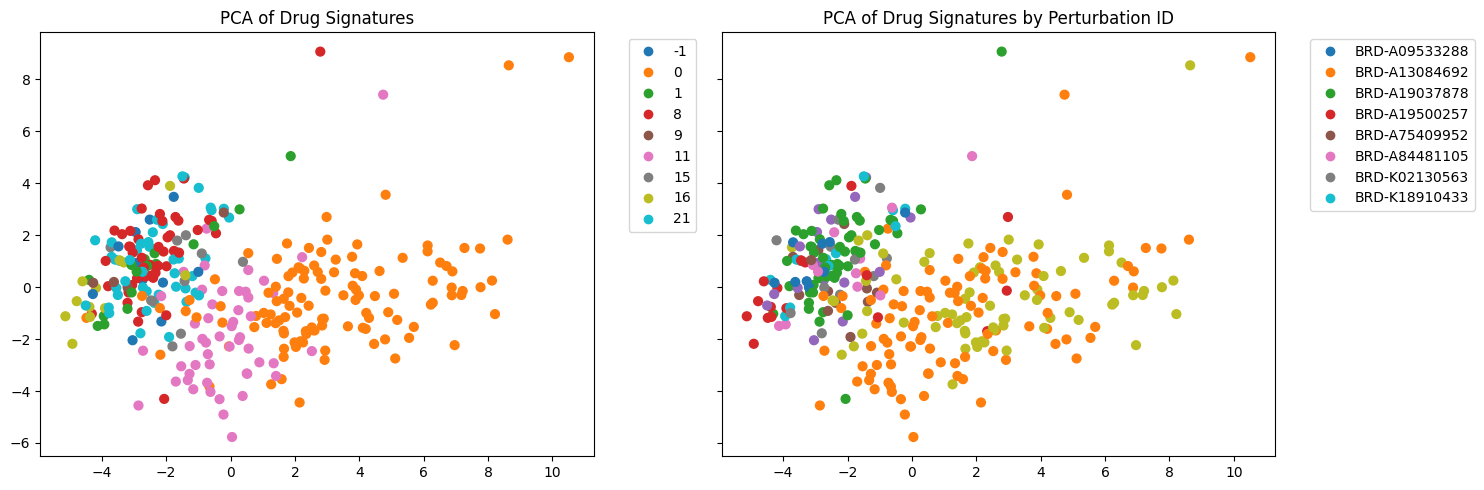

In [16]:
embeddings, labels = generate_embeddings(
    model,
    test_loader,
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
)

_, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True, sharey=True)
plot_pca(
    embeddings, df_meta_test["moa_int"], title="PCA of Drug Signatures", axes=axes[0]
)
plot_pca(
    embeddings,
    df_meta_test["pert_id"],
    title="PCA of Drug Signatures by Perturbation ID",
    axes=axes[1],
);

In [ ]:
def train_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    config: Dict[str, Any],
    beta: float,
    device: torch.device,
) -> Dict[str, float]:
    """Runs a single training epoch."""
    model.train()
    total_loss, total_recon, total_kl, total_class = 0, 0, 0, 0

    for condition, expression, moa_label in loader:
        expression, condition, moa_label = (
            expression.to(device),
            condition.to(device),
            moa_label.to(device),
        )

        optimizer.zero_grad()
        recon_x, mu, log_var = model(expression, condition)
        moa_prediction = model.classify(mu)

        # Calculate VAE and classification loss
        loss, recon, kl = vae_loss_function(
            recon_x,
            expression,
            mu,
            log_var,
            model.latent_dim,
            beta,
            recon_weight=config["alpha"],
        )
        mask = moa_label != -1
        class_loss = torch.tensor(0.0, device=device)
        if mask.sum() > 0:
            class_loss = nn.functional.cross_entropy(
                moa_prediction[mask], moa_label[mask]
            )

        total_epoch_loss = loss + config["gamma"] * class_loss
        total_epoch_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += total_epoch_loss.item()
        total_recon += recon.item()
        total_kl += kl.item()
        total_class += class_loss.item()

    # Return average losses for the epoch
    return {
        "loss": total_loss / len(loader),
        "recon": total_recon / len(loader),
        "kl": total_kl / len(loader),
        "class_loss": total_class / len(loader),
    }


def evaluate_epoch(
    model: nn.Module,
    loader: DataLoader,
    config: Dict[str, Any],
    beta: float,
    device: torch.device,
) -> Dict[str, float]:
    """Runs a single validation/evaluation epoch."""
    model.eval()
    total_loss, total_recon, total_kl, total_class = 0, 0, 0, 0

    with torch.no_grad():
        for condition, expression, moa_label in loader:
            expression, condition, moa_label = (
                expression.to(device),
                condition.to(device),
                moa_label.to(device),
            )
            recon_x, mu, log_var = model(expression, condition)
            moa_prediction = model.classify(mu)

            loss, recon, kl = vae_loss_function(
                recon_x,
                expression,
                mu,
                log_var,
                model.latent_dim,
                beta,
                recon_weight=config["alpha"],
            )
            mask = moa_label != -1
            class_loss = torch.tensor(0.0, device=device)
            if mask.sum() > 0:
                class_loss = nn.functional.cross_entropy(
                    moa_prediction[mask], moa_label[mask]
                )

            total_epoch_loss = loss + config["gamma"] * class_loss

            total_loss += total_epoch_loss.item()
            total_recon += recon.item()
            total_kl += kl.item()
            total_class += class_loss.item()

    return {
        "loss": total_loss / len(loader),
        "recon": total_recon / len(loader),
        "kl": total_kl / len(loader),
        "class_loss": total_class / len(loader),
    }


def create_animation_frames(
    epoch_history: list,
    animation_dir: str,
) -> list:
    """Creates PCA plots for each epoch and saves them as frames."""
    print("Generating animation frames...")
    # Fit PCA on the final epoch's embeddings for a stable projection
    final_embeddings = epoch_history[-1]["embeddings"]
    pca = PCA(n_components=2, random_state=42)
    pca.fit(final_embeddings)

    frame_files = []
    for i, epoch_data in enumerate(epoch_history):
        epoch_num = i + 1
        # Use the SAME fitted PCA to transform embeddings from every epoch
        projected_embeddings = pca.transform(epoch_data["embeddings"])

        fig, ax = plt.subplots(figsize=(10, 8))
        ax.scatter(
            projected_embeddings[:, 0],
            projected_embeddings[:, 1],
            c=epoch_data["labels"],
            cmap="tab10",
            s=40,
        )
        ax.set_title(f"Latent Space PCA - Epoch {epoch_num}")

        frame_path = os.path.join(animation_dir, f"epoch_{epoch_num:03d}.png")
        plt.savefig(frame_path, bbox_inches="tight", dpi=100)
        plt.close(fig)
        frame_files.append(frame_path)

    return frame_files


def build_animation_gif(
    frame_files: list,
    output_path: str,
    duration: float = 0.5,
):
    """Builds a GIF from a list of frame files."""
    print("Creating animation...")
    with imageio.get_writer(output_path, mode="I", duration=duration) as writer:
        for filename in frame_files:
            image = imageio.imread(filename)
            writer.append_data(image)
    print(f"Animation saved to {output_path}")


def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    test_loader: DataLoader,  
    config: Dict[str, Any],
    device: torch.device,
) -> Tuple[nn.Module, Dict[str, list]]:
    """
    Main orchestrator for training the model, logging, and creating an animation.
    """
    run_name = f"cvae_model_{config['latent_dim']}latent_{config['hidden_dim']}hidden"
    animation_dir = os.path.join(ROOT, "imgs", run_name, "animation_frames")
    os.makedirs(animation_dir, exist_ok=True)

    wandb.init(
        project="drug-induced-gene-expression-prediction", config=config, name=run_name
    )
    optimizer = torch.optim.Adam(
        model.parameters(), lr=config["learning_rate"], weight_decay=1e-5
    )
    model.to(device)

    history = {
        k: []
        for k in [
            "train_loss",
            "val_loss",
            "train_recon",
            "val_recon",
            "train_kl",
            "val_kl",
            "train_class_loss",
            "val_class_loss",
        ]
    }
    animation_data = []

    # Main Training Loop 
    pbar_epochs = tqdm(range(1, config["num_epochs"] + 1), desc="Overall Progress")
    for epoch in pbar_epochs:
        beta = (
            config["beta"] * ((epoch - 1) / config["num_epochs"])
            if config.get("beta_anneal")
            else config["beta"]
        )

        train_metrics = train_epoch(
            model, train_loader, optimizer, config, beta, device
        )
        val_metrics = evaluate_epoch(model, val_loader, config, beta, device)

        for key in train_metrics:
            history[f"train_{key}"].append(train_metrics[key])
            history[f"val_{key}"].append(val_metrics[key])

        wandb.log(
            {
                "Train Loss": train_metrics["loss"],
                "Val Loss": val_metrics["loss"],
                "Train Recon": train_metrics["recon"],
                "Val Recon": val_metrics["recon"],
                "Train KL": train_metrics["kl"],
                "Val KL": val_metrics["kl"],
                "Train Class Loss": train_metrics["class_loss"],
                "Val Class Loss": val_metrics["class_loss"],
                "Beta": beta,
                "Epoch": epoch,
            },
            step=epoch,
        )

        # Generate and store data for animation
        test_embeddings, test_labels = generate_embeddings(model, test_loader, device)
        animation_data.append({"embeddings": test_embeddings, "labels": test_labels})
        pbar_epochs.set_postfix(
            {
                "Train Loss": f"{train_metrics['loss']:.4f}",
                "Val Loss": f"{val_metrics['loss']:.4f}",
            }
        )

    # Create and Log Animation 
    frame_files = create_animation_frames(animation_data, animation_dir)
    animation_path = os.path.join(ROOT, "imgs", run_name, "training_animation.gif")
    build_animation_gif(frame_files, animation_path, duration=0.5)
    wandb.log({"training_animation": wandb.Video(animation_path, fps=2, format="gif")})

    # Cleanup and Return
    wandb.finish()
    return model, history

In [18]:
model, history = train_model(
    model,
    train_loader,
    val_loader,
    test_loader,
    config,
    device="mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu",
)

wandb: Currently logged in as: dantrainer01 (dantrainer01-none) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Overall Progress: 100%|██████████| 50/50 [04:11<00:00,  5.03s/it, Train Loss=1488.0245, Val Loss=1504.5822]


Generating animation frames...
Creating animation...


/var/folders/wt/5vc39b651nn6m5wm29j25dk80000gn/T/ipykernel_26188/1767595289.py:156: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(filename)
wandb: WARNING `fps` argument does not affect the frame rate of the video when providing a file path or raw bytes.


Animation saved to /Users/dantrainer/projects/cancer_research/imgs/cvae_model_32latent_128hidden/training_animation.gif


Beta,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
Train Class Loss,███▇▇▆▆▆▅▅▅▅▄▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
Train KL,▁▂▃▄▄▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇████████████████
Train Loss,█▆▅▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Train Recon,█▆▅▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Val Class Loss,██▇▇▇▆▆▆▆▅▅▅▅▅▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁
Val KL,▁▂▃▃▄▅▅▆▆▆▇▆▇▇▇▇▇▇▇▇█▇▇▇▇▇██▇▇██████████
Val Loss,█▆▆▅▅▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Val Recon,█▆▆▅▅▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Beta,0.2


#### Visualize the training curves

/var/folders/wt/5vc39b651nn6m5wm29j25dk80000gn/T/ipykernel_26188/1349306737.py:32: UserWarning: Mismatched number of handles and labels: len(handles) = 8 len(labels) = 20
  axes.legend(


<Axes: title={'center': 'PCA of Drug Signatures by Perturbation ID'}>

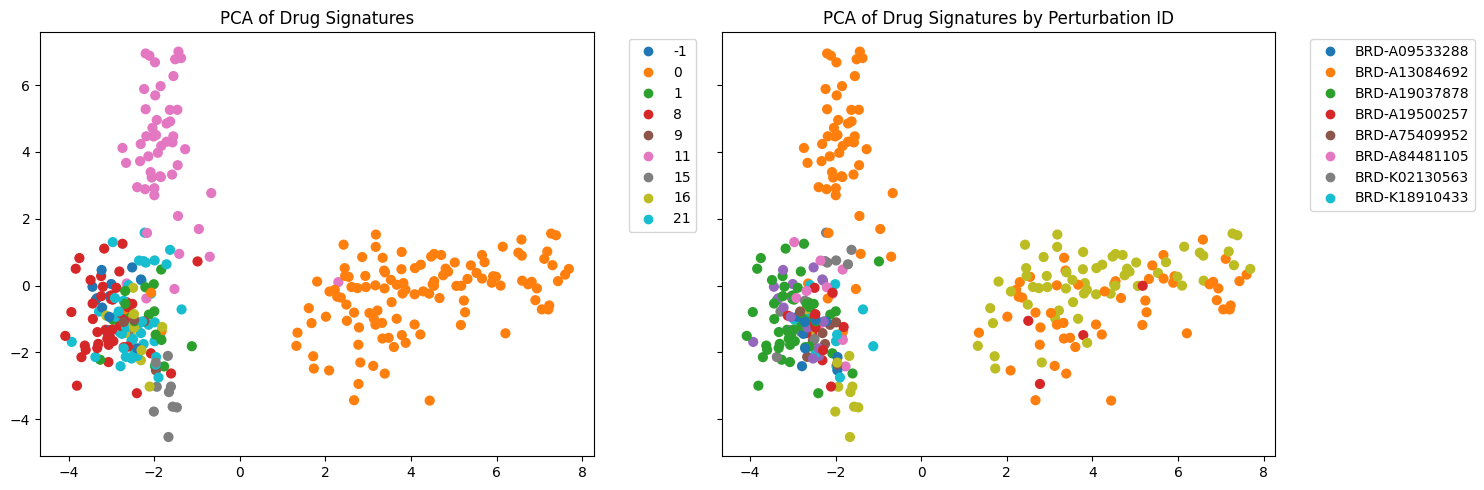

In [21]:
embeddings, labels = generate_embeddings(
    model,
    test_loader,
    device="mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu",
)

_, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True, sharey=True)
plot_pca(
    embeddings, df_meta_test["moa_int"], title="PCA of Drug Signatures", axes=axes[0]
)
plot_pca(
    embeddings,
    df_meta_test["pert_id"],
    title="PCA of Drug Signatures by Perturbation ID",
    axes=axes[1],
)

/var/folders/wt/5vc39b651nn6m5wm29j25dk80000gn/T/ipykernel_26188/1349306737.py:32: UserWarning: Mismatched number of handles and labels: len(handles) = 9 len(labels) = 23
  axes.legend(
/var/folders/wt/5vc39b651nn6m5wm29j25dk80000gn/T/ipykernel_26188/1349306737.py:32: UserWarning: Mismatched number of handles and labels: len(handles) = 12 len(labels) = 1149
  axes.legend(


<Axes: title={'center': 'PCA of Drug Signatures by Perturbation ID'}>

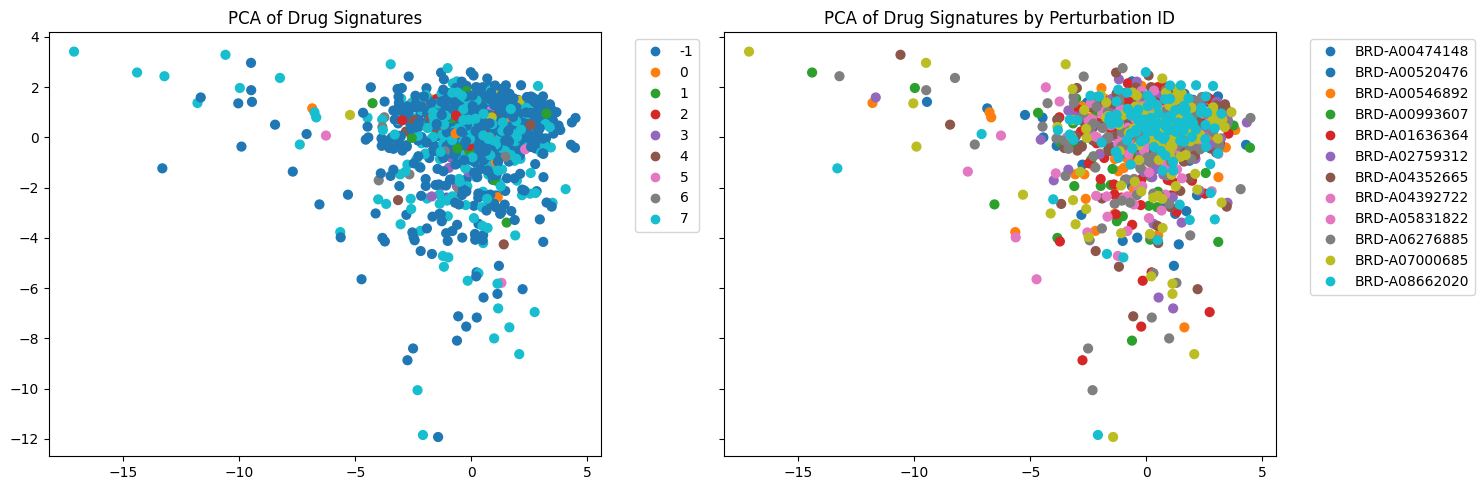

In [22]:
embeddings, labels = generate_embeddings(
    model,
    val_loader,
    device="mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu",
)

_, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True, sharey=True)
plot_pca(
    embeddings, df_meta_val["moa_int"], title="PCA of Drug Signatures", axes=axes[0]
)
plot_pca(
    embeddings,
    df_meta_val.index,
    title="PCA of Drug Signatures by Perturbation ID",
    axes=axes[1],
)

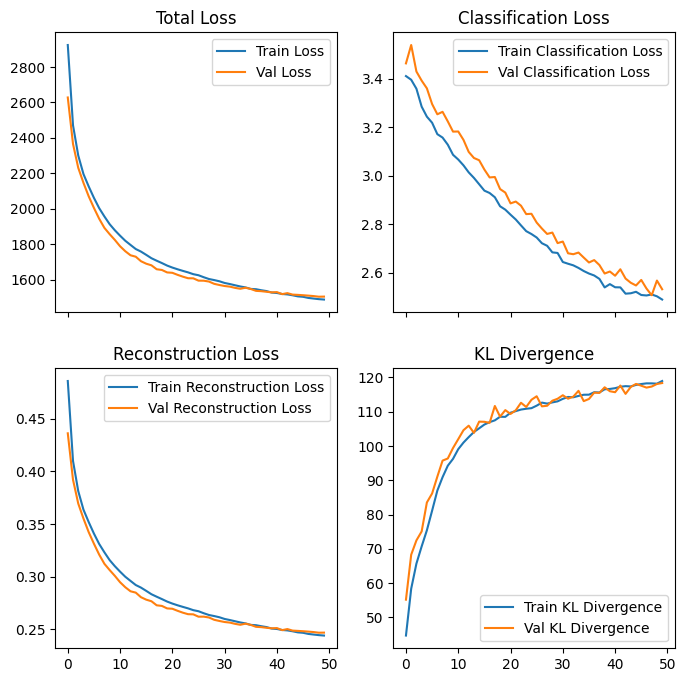

In [23]:
plot_training_history(history)

In [24]:
import gseapy


def get_control_and_test_profiles(
    pert_id_to_test, pert_id_control, dataset, df_gene, model, device
):
    """
    Get the control and test profiles for a given perturbation ID.

    Args:
        pert_id_to_test (str): The perturbation ID to test.
        dataset (LincsDataset): The dataset containing the profiles.
        pert_id_control (str, optional): The control perturbation ID. Defaults to "DMSO".

    Returns:
        tuple: Condition and expression tensors for the test and control profiles.
    """

    condition_x, expression_x, _ = dataset.get_item_by_pert_id(pert_id_to_test)
    # _, expression_dmso, _ = dataset.get_item_by_pert_id(
    #     pert_id_control
    # )

    control_profile = dataset.df_expression.mean()

    all_gene_names = control_profile.index.tolist()
    all_gene_names = (
        df_gene[["pr_gene_id", "pr_gene_symbol"]]
        .set_index("pr_gene_id")
        .loc[control_profile.index.astype(int)]
        .values.squeeze()
        .tolist()
    )
    control_x = control_profile.values
    # control_x = expression_dmso.squeeze().detach().cpu().numpy()

    condition_x = condition_x.unsqueeze(0).to(device)
    expression_x = expression_x.unsqueeze(0).to(device)

    recon_x, _, _ = model(expression_x, condition_x)

    return expression_x, condition_x, recon_x, control_x, all_gene_names


def get_monte_carlo_generation(condition_x, model, device, num_samples=1000):
    all_generated_profiles = []
    for i in range(num_samples):
        torch.manual_seed(i)
        # Generate a new random latent vector
        z = torch.randn(condition_x.shape[0], model.latent_dim).to(device)
        c_embs = model.molecular_embedding(condition_x)

        z = torch.cat((z, c_embs), dim=1)

        generated_x = model.decoder(z)

        all_generated_profiles.append(generated_x.detach().cpu())

    mean_generated_x = torch.mean(torch.stack(all_generated_profiles), dim=0)

    return mean_generated_x


def calculate_log2_fold_change_from_control(recon_x, control_np, all_gene_names):
    """Calculate log2 fold change from the control profile.

    Args:
        recon_x (torch.Tensor): The reconstructed gene expression profile.
        control_np (np.ndarray): The control gene expression profile.
        all_gene_names (list): List of gene names corresponding to the expression profiles.
    """
    recon_x_np = recon_x.detach().cpu().numpy()
    log2_fold_change = recon_x_np - control_np

    ranked_gene_df = pd.DataFrame(
        {"gene_name": all_gene_names, "log2fc": log2_fold_change.squeeze()}
    )

    return ranked_gene_df.sort_values(by="log2fc", ascending=False)


def get_gsea_prerank(recon_x, control_np, all_gene_names):
    """Get the GSEA prerank DataFrame."""
    ranked_gene_df = calculate_log2_fold_change_from_control(
        recon_x, control_np, all_gene_names
    )
    prerank_obj = gseapy.prerank(
        rnk=ranked_gene_df, gene_sets="KEGG_2021_Human", seed=42
    )

    results_df = prerank_obj.res2d

    ranked_gene_df = ranked_gene_df.set_index("gene_name")
    significant_results = results_df[results_df["FDR q-val"] < 0.05]

    return significant_results


def evaluate_recon_and_gen_gsea_for_pert(
    pert_id_to_test, pert_id_control, val_dataset, df_gene, img_save_path, model, device
):
    expression_x, condition_x, recon_x, control_x, all_gene_names = (
        get_control_and_test_profiles(
            pert_id_to_test, pert_id_control, val_dataset, df_gene, model, device
        )
    )

    mean_generated_x = get_monte_carlo_generation(condition_x, model, device)

    df_generated_results = get_gsea_prerank(mean_generated_x, control_x, all_gene_names)
    df_expression_results = get_gsea_prerank(expression_x, control_x, all_gene_names)
    df_reconstructed_results = get_gsea_prerank(recon_x, control_x, all_gene_names)

    df_results = pd.concat(
        [
            df_expression_results.set_index("Term")["ES"],
            df_reconstructed_results.set_index("Term")["ES"],
            df_generated_results.set_index("Term")["ES"],
        ],
        axis=1,
        keys=[
            "Original Expression",
            "Reconstructed Expression",
            "Generated Expression",
        ],
    )

    df_results = df_results.dropna(subset="Original Expression")
    df_results = df_results.fillna(0)

    gsea_recon_error = (
        np.abs(
            df_results["Original Expression"] - df_results["Reconstructed Expression"]
        )
        .sum()
        .tolist()
    )
    gsea_gen_error = (
        np.abs(df_results["Original Expression"] - df_results["Generated Expression"])
        .sum()
        .tolist()
    )

    df_plot = pd.melt(
        df_results.dropna(subset="Original Expression").iloc[:10].reset_index(),
        id_vars=["Term"],
        var_name="Profile Type",
        value_name="Enrichment Score",
    )

    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid")

    # Create the bar plot
    ax = sns.barplot(
        data=df_plot,
        y="Term",
        x="Enrichment Score",
        hue="Profile Type",
        orient="h",
    )

    # Add a vertical line at zero for reference
    ax.axvline(0, color="black", lw=1)
    ax.grid(False)
    ax.set_title("GSEA Comparison for Bortezomib", fontsize=16)
    ax.set_xlabel("Normalized Enrichment Score (NES)", fontsize=12)
    ax.set_ylabel("")
    plt.legend(title="Profile Source")

    plt.savefig(os.path.join(img_save_path, "gsea_comparison.png"))

    return gsea_recon_error, gsea_gen_error


In [25]:
def get_recon_correlation(model, train_loader, val_loader, img_save_path):
    train_expression = []
    train_reconstruction = []
    for condition, expression, moa_label in train_loader:
        recon_x, mu, log_var = model(expression, condition)
        train_reconstruction.append(recon_x.detach().cpu().numpy())
        train_expression.append(expression.detach().cpu().numpy())

    train_expression = np.vstack(train_expression)
    train_reconstruction = np.vstack(train_reconstruction)

    val_expression = []
    val_reconstruction = []
    for condition, expression, moa_label in val_loader:
        recon_x, mu, log_var = model(expression, condition)
        val_reconstruction.append(recon_x.detach().cpu().numpy())
        val_expression.append(expression.detach().cpu().numpy())
    val_expression = np.vstack(val_expression)
    val_reconstruction = np.vstack(val_reconstruction)

    val_corr = np.corrcoef(val_reconstruction.flatten(), val_expression.flatten())
    train_corr = np.corrcoef(train_reconstruction.flatten(), train_expression.flatten())

    _, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=False)
    axes[0].hist(
        train_reconstruction.flatten() - train_expression.flatten(),
        bins=np.linspace(-3, 3, 20),
        alpha=0.5,
        label="Training Data",
    )
    axes[1].hist(
        val_reconstruction.flatten() - val_expression.flatten(),
        bins=np.linspace(-3, 3, 20),
        alpha=0.5,
        label="Validation Data",
    )
    axes[0].set_title(
        "Distribution of Reconstruction Residuals (Training Data)\nCorrelation: {:.2f}".format(
            train_corr[0, 1]
        )
    )
    axes[1].set_title(
        "Distribution of Reconstruction Residuals (Validation Data)\nCorrelation: {:.2f}".format(
            val_corr[0, 1]
        )
    )
    axes[0].set_xlabel("Reconstructed Residuals")
    axes[0].set_ylabel("Frequency")
    axes[1].set_xlabel("Reconstructed Residuals")
    plt.tight_layout()

    plt.savefig(os.path.join(img_save_path, "residuals.png"))

    return train_corr[0, 1], val_corr[0, 1]


2025-07-18 15:10:47,080 [WARNING] Duplicated values found in preranked stats: 0.02% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2025-07-18 15:10:54,433 [WARNING] Duplicated values found in preranked stats: 0.02% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
/var/folders/wt/5vc39b651nn6m5wm29j25dk80000gn/T/ipykernel_60929/2543490325.py:120: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_results = df_results.fillna(0)


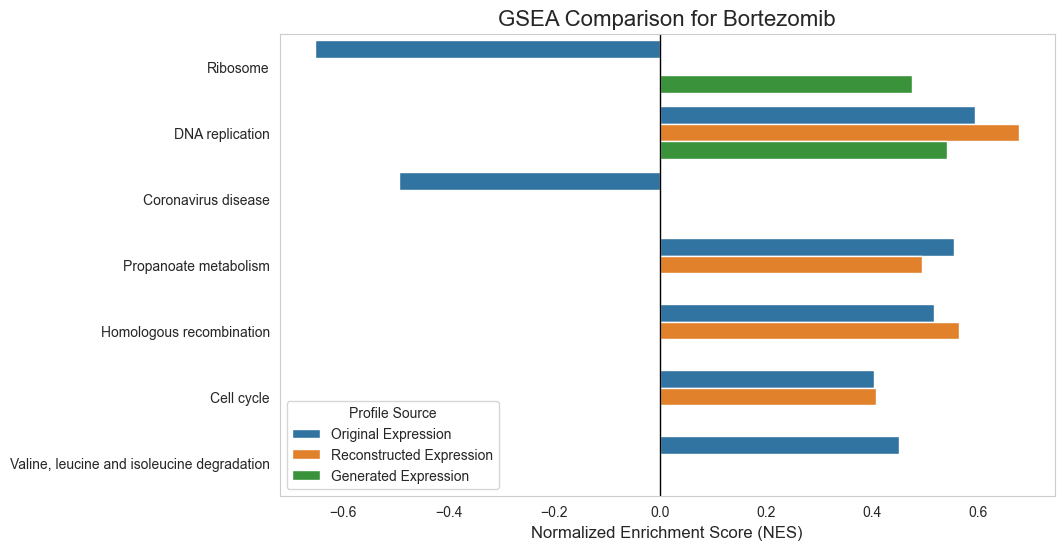

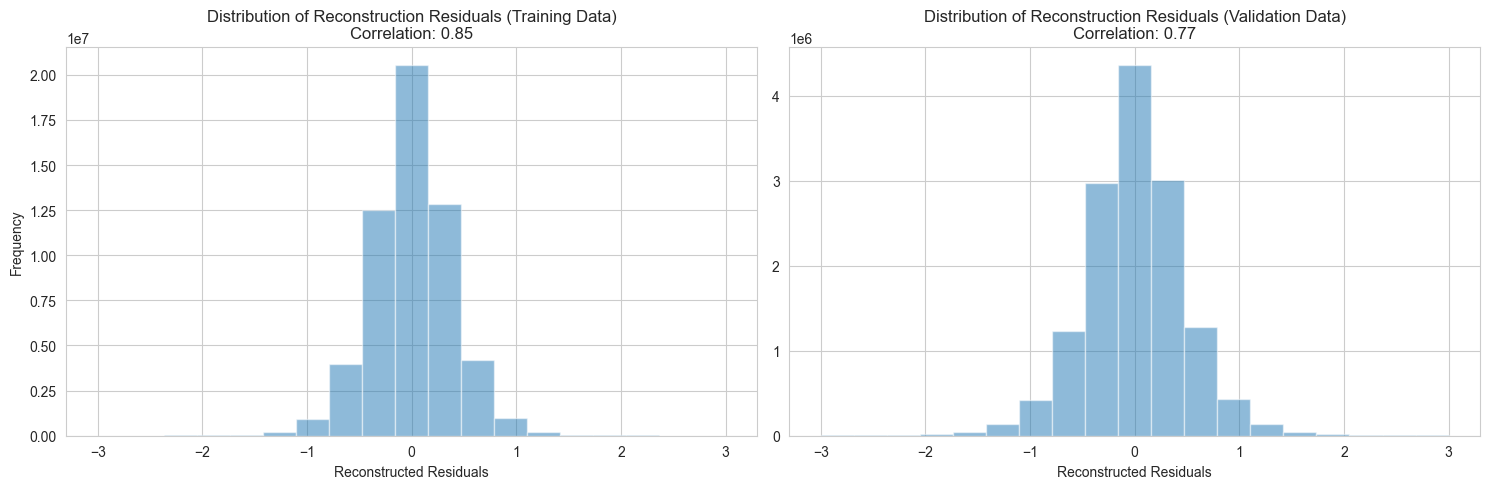

In [ ]:
img_save_path = ROOT
gsea_recon_error, gsea_gen_error = evaluate_recon_and_gen_gsea_for_pert(
    pert_id_to_test="BRD-A00993607",
    pert_id_control="DMSO",
    val_dataset=val_loader.dataset,
    df_gene=df_gene,
    img_save_path=img_save_path,
    model=model,
    device=device,
)

train_corr, val_corr = get_recon_correlation(
    model, train_loader, val_loader, img_save_path
)

**Observations**:

* The model demonstrates reasonable training stability. The training and validation loss curves for the Total, Reconstruction, and Classification losses track each other closely without diverging, which indicates the model is generalizing well to unseen data and is not suffering from significant overfitting.

* The VAE is effectively balancing its three competing objectives. The reconstruction loss is decreasing, the classification loss is decreasing, and the KL divergence has settled into a stable range, showing that all components of the semi-supervised model are learning successfully.

* The KL Divergence plot is particularly informative. The fact that the KLD stabilizes at a healthy, non-zero value (around 4.5-5.5) confirms that the model has avoided posterior collapse. This is a strong indicator that the latent space is being properly regularized while still retaining meaningful information.

---
### 7. Summary

This notebook establishes the foundational data processing pipeline and a stable training framework for a semi-supervised Conditional Variational Autoencoder (CVAE). The primary goal is to create a model that learns a meaningful relationship between a drug's chemical structure and its impact on gene expression.


The primary findings include:

* **Data Pipeline Established**: The LINCS L1000 gene expression data and corresponding chemical fingerprints have been successfully processed, normalized, and integrated into a custom PyTorch Dataset for model training.

* **Semi-Supervised CVAE Implemented**: A robust CVAE architecture has been implemented, featuring dedicated modules for encoding, decoding, and processing conditional information. The model is enhanced with a classification head to leverage Mechanism of Action (MoA) labels, guiding the model to learn a more biologically structured latent space.

* **Stable Training Achieved**: After iterative debugging of numerical instabilities, a stable training loop has been achieved. The model's loss curves demonstrate successful learning and convergence without significant overfitting or gradient explosion issues, providing a solid baseline for further analysis and optimization.

#### Next Steps

The current model is technically sound, but its biological relevance has not yet been rigorously validated. The following steps will be taken to assess and improve the model's ability to generate meaningful biological insights.

1. **Quantitative Biological Validation**: perform Gene Set Enrichment Analysis (GSEA) on generated profiles for well-characterized drugs (e.g., Bortezomib). The primary goal is to verify if the VAE can generate a gene expression profile that correctly enriches for the known biological pathways associated with the drug's mechanism of action.

2. **In-Depth Latent Space Analysis**: move beyond broad UMAP plots and create focused visualizations of the latent space. By plotting the "drug effect vector" for potent compounds against a control baseline, we can directly assess if the model has organized its latent space along meaningful biological axes.

3. **Targeted Hyperparameter Optimization**: fine-tune key hyperparameters based on GSEA analysis. This includes adjusting the balance between the loss terms (beta for KLD, gamma for classification) and optimizing the architectural complexity (e.g., latent dimension, decoder depth) to improve the reliability of the generative process.

In [ ]:
drug_pert_id = ["BRD-A00993607", "BRD-K63089472", "BRD-K45988865", "BRD-A45206415"]

drug_sig_ids = df_sig[df_sig["pert_id"].isin(drug_pert_id)]["sig_id"]
drug_sig_ids = set(drug_sig_ids.tolist())
drug_sig_ids = list(drug_sig_ids)

dmso_sig_ids = df_sig[df_sig["pert_iname"] == "DMSO"].sample(20)["sig_id"]
dmso_sig_ids = set(dmso_sig_ids.tolist())
dmso_sig_ids = list(dmso_sig_ids)

# drug_sig_ids.extend(dmso_sig_ids)

drug_sig_ids

['CPC001_HCC515_24H:BRD-K45988865-001-01-0:10',
 'NMH002_NPC_6H:BRD-K63089472-001-04-3:10',
 'CPC003_VCAP_24H:BRD-K63089472-001-02-7:10',
 'CPC003_VCAP_6H:BRD-K63089472-001-02-7:10',
 'CPC018_ASC_24H:BRD-K63089472-001-03-5:10',
 'CPC009_HT29_6H:BRD-A45206415-001-05-5:10',
 'CPC004_MCF7_6H:BRD-A00993607-003-15-4:10',
 'CPC003_PC3_6H:BRD-K63089472-001-02-7:10',
 'CPC009_HEPG2_6H:BRD-A45206415-001-05-5:10',
 'CPC003_HA1E_6H:BRD-K63089472-001-02-7:10',
 'CPC003_PC3_24H:BRD-K63089472-001-02-7:10',
 'CPC004_HCC515_6H:BRD-A00993607-003-15-4:10',
 'CPC016_MCF7_6H:BRD-K45988865-001-01-0:10',
 'CPC001_VCAP_6H:BRD-K45988865-001-01-0:10',
 'CPC009_VCAP_24H:BRD-A45206415-001-05-5:10',
 'CPC016_NEU_24H:BRD-A00993607-003-15-4:10',
 'CPC016_A549_6H:BRD-K45988865-001-01-0:10',
 'CPC004_HCC515_24H:BRD-A00993607-003-15-4:10',
 'CPC004_HEPG2_6H:BRD-A00993607-003-15-4:10',
 'CPC018_NPC_24H:BRD-K63089472-001-03-5:10',
 'CPC016_ASC_24H:BRD-K45988865-001-01-0:10',
 'CPC018_A549_24H:BRD-K63089472-001-03-5:10',

In [ ]:
df_averaged

,BRD-A00100033,BRD-A00267231,BRD-A00420644,BRD-A00474148,BRD-A00520476,BRD-A00546892,BRD-A00626522,BRD-A00758722,BRD-A00827783,BRD-A00993607,...,BRD-U51951544,BRD-U66370498,BRD-U68942961,BRD-U73238814,BRD-U82589721,BRD-U86922168,BRD-U88459701,BRD-U94846492,BRD-U97083655,DMSO
rid,,,,,,,,,,,,,,,,,,,,,
5720,0.826567,-0.568241,-2.189991,0.723845,-0.48505,0.217919,-0.55540,-1.264430,0.491229,0.112275,...,-1.33120,-0.045422,-2.841073,0.458586,-1.574413,-3.381999,0.130841,0.267506,0.331280,-0.063473
466,0.284471,0.703532,-1.198357,-0.820021,-0.92530,-0.103425,0.32280,-0.494967,0.465437,0.260624,...,-2.67475,-0.051166,-3.271909,0.744136,-1.011487,-0.525395,-0.857952,0.781003,0.622388,-0.080132
6009,-0.549101,0.357067,2.009591,-0.113706,-1.59015,-0.367488,-0.28730,0.466556,0.675874,-0.027216,...,-1.95965,0.042122,-0.231894,-0.291170,-0.020680,-0.311100,-0.676564,0.352920,0.284077,-0.008120
2309,-1.414383,-1.305485,2.530965,0.136478,-1.78720,0.285799,-0.02985,-0.001455,-1.215721,-0.088118,...,-4.38085,-0.963460,2.582773,0.101156,-1.336719,3.039191,0.261088,0.087820,-0.649788,-0.107903
387,0.298028,-0.370013,0.410572,-0.210709,-0.47810,-0.101240,0.43780,-0.099972,-0.004129,-0.588786,...,0.41375,-0.774725,-0.044668,-0.188228,0.754848,-0.368882,3.442191,0.252630,0.016547,0.096396
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25960,-0.702823,0.389050,0.411424,-0.375076,0.57180,0.207068,-0.14505,0.373843,0.198210,0.499721,...,2.61460,1.613346,-0.272428,-0.980646,0.781393,0.193665,-1.372155,-0.219194,-0.114598,-0.035062
6376,-1.135657,0.010203,0.590206,-0.765630,-0.39100,-0.374216,0.10400,-0.246971,0.398666,-0.416996,...,0.95975,1.310484,0.017481,0.295986,-0.653096,-0.083449,0.203162,0.817905,-0.229802,-0.006366
11033,-1.214979,-0.113850,1.304059,0.163355,1.75985,0.486852,-0.78950,-0.738267,0.093434,-0.203176,...,1.12640,0.493943,-0.023583,-1.088944,1.204358,1.144818,-0.604002,0.679328,-0.367433,-0.045705
